# Credit Card Fraud Detection Using Machine Learning

# Week 3: Data Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [3]:
df = pd.read_csv("data/raw/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (284807, 30)
Target shape: (284807,)


In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (199364, 30)
Validation set: (42721, 30)
Test set: (42722, 30)


In [6]:
print("Class distribution in training set before SMOTE:")
print(y_train.value_counts())

print("\nPercentage distribution before SMOTE:")
print(y_train.value_counts(normalize=True) * 100)

Class distribution in training set before SMOTE:
Class
0    199020
1       344
Name: count, dtype: int64

Percentage distribution before SMOTE:
Class
0    99.827451
1     0.172549
Name: proportion, dtype: float64


In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [8]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

In [9]:
print("Class distribution in training set after SMOTE:")
print(pd.Series(y_train_smote).value_counts())

print("\nPercentage distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts(normalize=True) * 100)

Class distribution in training set after SMOTE:
Class
0    199020
1    199020
Name: count, dtype: int64

Percentage distribution after SMOTE:
Class
0    50.0
1    50.0
Name: proportion, dtype: float64


In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_smote, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [11]:
y_pred = model.predict(X_test_scaled)

In [12]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[41692   956]
 [    9    65]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     42648
           1       0.06      0.88      0.12        74

    accuracy                           0.98     42722
   macro avg       0.53      0.93      0.55     42722
weighted avg       1.00      0.98      0.99     42722



In [13]:
from sklearn.metrics import roc_auc_score

roc = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", roc)

ROC-AUC Score: 0.9279811606767151


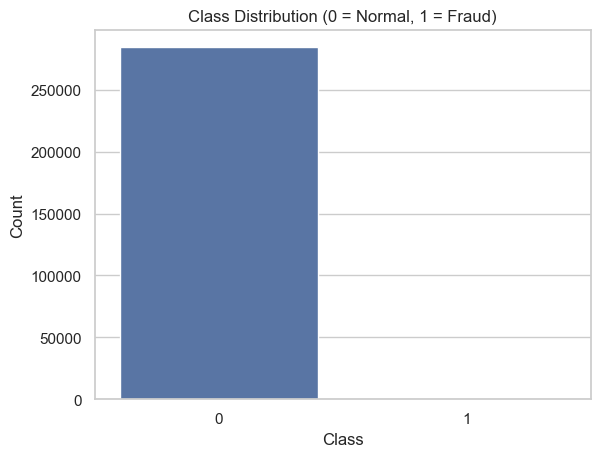

In [14]:
# Class count
sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0 = Normal, 1 = Fraud)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [15]:
class_counts = df['Class'].value_counts(normalize=True) * 100

print("Class Percentage Distribution:")
print(class_counts)

Class Percentage Distribution:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


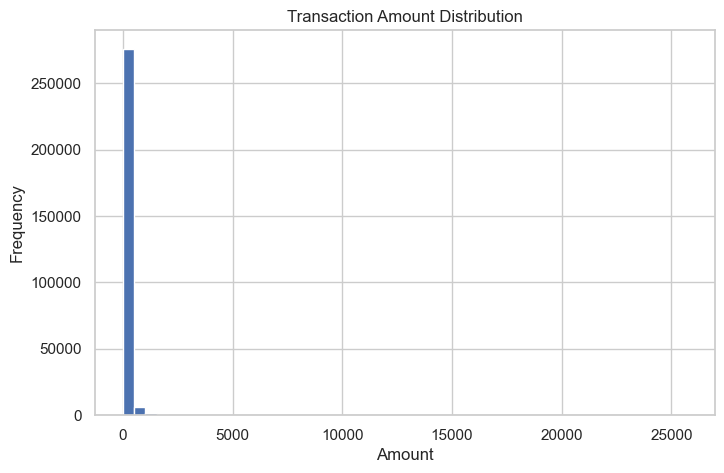

In [16]:
plt.figure(figsize=(8,5))
plt.hist(df['Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

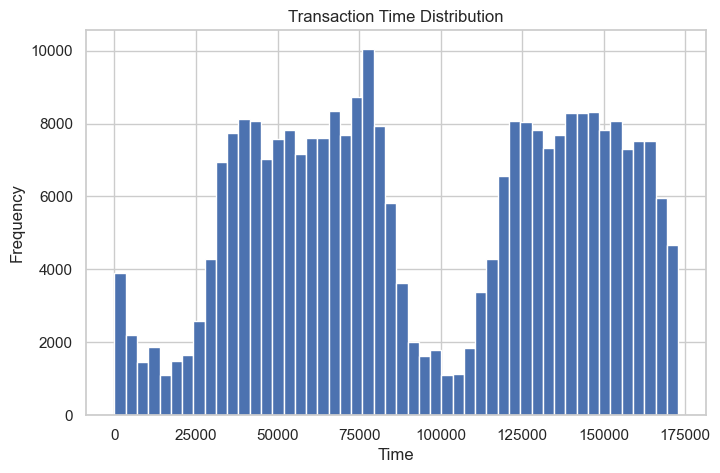

In [17]:
plt.figure(figsize=(8,5))
plt.hist(df['Time'], bins=50)
plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()

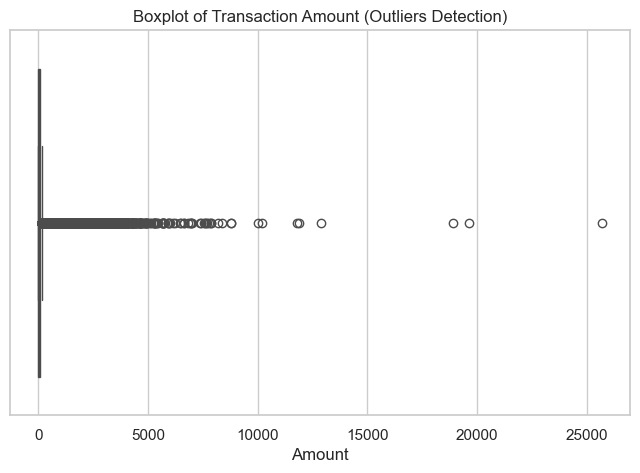

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Amount'])
plt.title("Boxplot of Transaction Amount (Outliers Detection)")
plt.show()

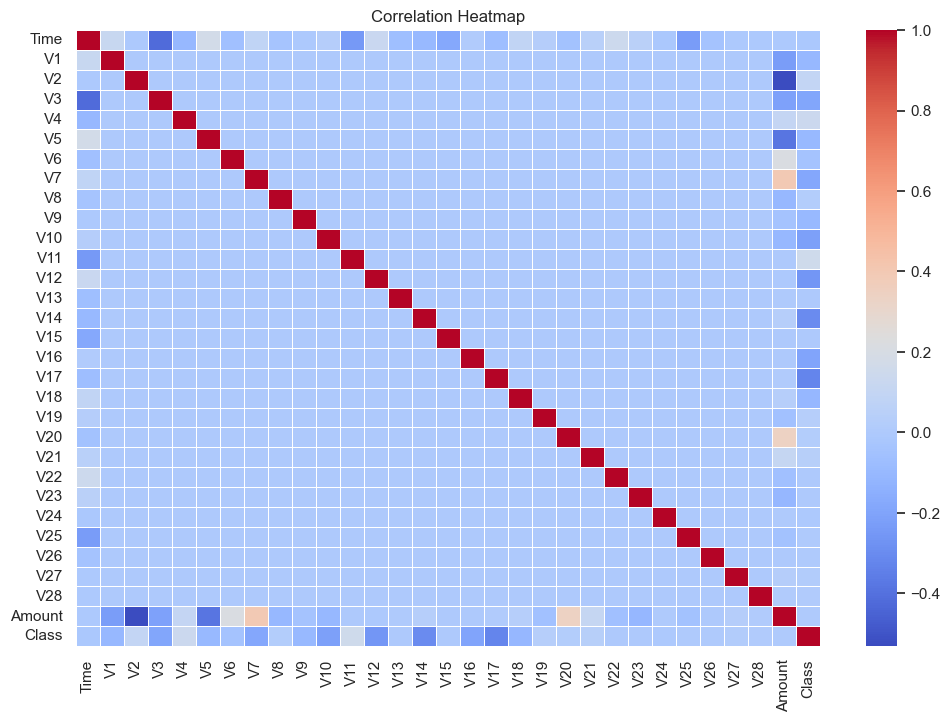

In [19]:
plt.figure(figsize=(12,8))
corr = df.corr()

sns.heatmap(corr, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

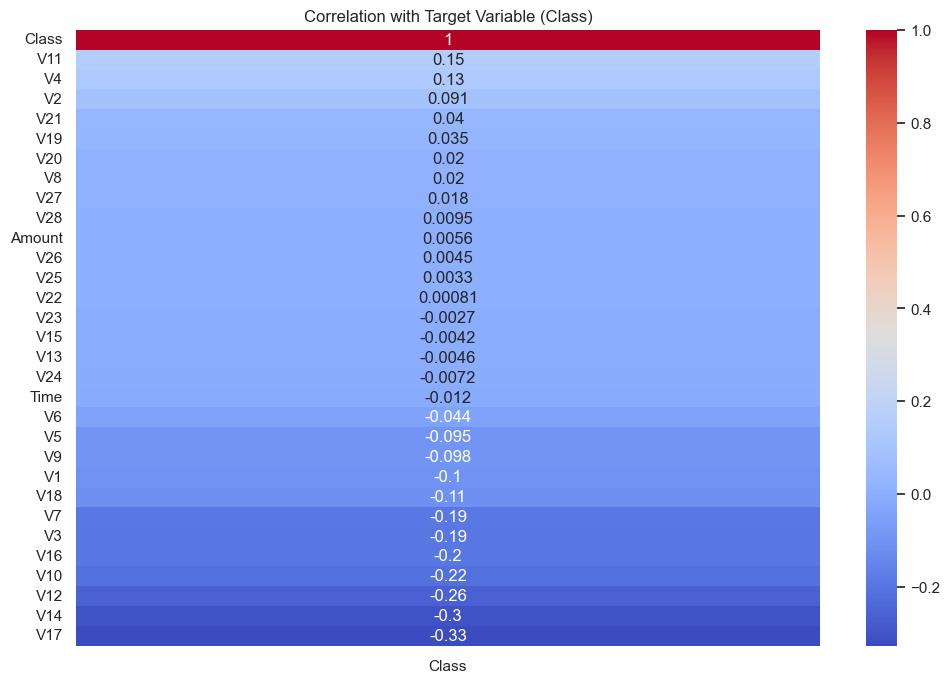

In [20]:
plt.figure(figsize=(12,8))
corr = df.corr()

sns.heatmap(corr[['Class']].sort_values(by='Class', ascending=False),
            cmap='coolwarm', annot=True)

plt.title("Correlation with Target Variable (Class)")
plt.show()

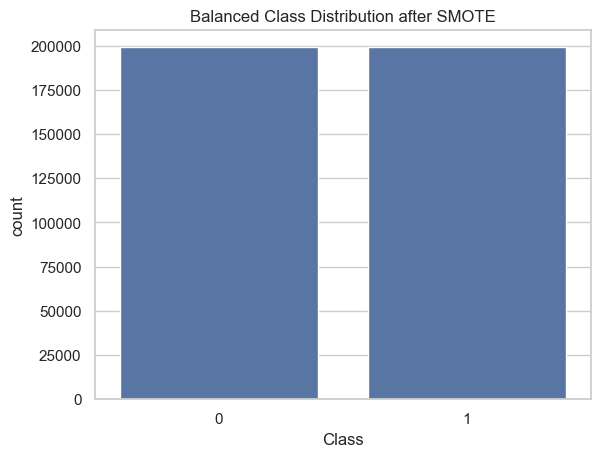

In [21]:
# Convert to DataFrame for plotting
smote_df = pd.DataFrame(y_train_smote, columns=['Class'])

sns.countplot(x='Class', data=smote_df)
plt.title("Balanced Class Distribution after SMOTE")
plt.show()

In [22]:
import numpy as np

# Log transformation (handles skewness)
df['Amount_log'] = np.log1p(df['Amount'])

# Time in hours (more interpretable)
df['Time_hours'] = df['Time'] / 3600

# Transaction intensity (relative scale)
df['Amount_scaled_manual'] = df['Amount'] / df['Amount'].max()

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V24,V25,V26,V27,V28,Amount,Class,Amount_log,Time_hours,Amount_scaled_manual
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,5.014760,0.000000,0.005824
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,1.305626,0.000000,0.000105
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,5.939276,0.000278,0.014739
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,4.824306,0.000278,0.004807
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,4.262539,0.000556,0.002724


In [23]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Time                    0
V1                      0
V2                      0
V3                      0
V4                      0
V5                      0
V6                      0
V7                      0
V8                      0
V9                      0
V10                     0
V11                     0
V12                     0
V13                     0
V14                     0
V15                     0
V16                     0
V17                     0
V18                     0
V19                     0
V20                     0
V21                     0
V22                     0
V23                     0
V24                     0
V25                     0
V26                     0
V27                     0
V28                     0
Amount                  0
Class                   0
Amount_log              0
Time_hours              0
Amount_scaled_manual    0
dtype: int64


In [24]:
print("Number of duplicate records:")
print(df.duplicated().sum())

Number of duplicate records:
1081


In [25]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V24,V25,V26,V27,V28,Amount,Class,Amount_log,Time_hours,Amount_scaled_manual
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,5.014760,0.000000,0.005824
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,1.305626,0.000000,0.000105
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,5.939276,0.000278,0.014739
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,4.824306,0.000278,0.004807
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,4.262539,0.000556,0.002724


In [26]:
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Amount'] < lower) | (df['Amount'] > upper)]

print("Number of outliers:", len(outliers))

Number of outliers: 31904


In [27]:
df['Amount_capped'] = np.clip(df['Amount'], lower, upper)

df[['Amount', 'Amount_capped']].head()

,Amount,Amount_capped
0,149.62,149.6200
1,2.69,2.6900
2,378.66,184.5125
3,123.50,123.5000
4,69.99,69.9900


In [28]:
print("Final dataset shape:", df.shape)

Final dataset shape: (284807, 35)


# Week 4: Model Development and Evaluation

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [30]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_smote, y_train_smote)
print("Model training completed")

Model training completed


In [31]:
y_pred_rf = rf_model.predict(X_test_scaled)

In [32]:
print("Confusion Matrix (Random Forest):")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))

Confusion Matrix (Random Forest):
[[42642     6]
 [   15    59]]

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42648
           1       0.91      0.80      0.85        74

    accuracy                           1.00     42722
   macro avg       0.95      0.90      0.92     42722
weighted avg       1.00      1.00      1.00     42722



In [33]:
import pandas as pd

feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)

feature_importance.sort_values(ascending=False).head(10)

V14    0.198684
V4     0.116661
V10    0.109597
V12    0.094804
V17    0.084141
V16    0.056905
V3     0.054108
V11    0.048982
V2     0.038478
V9     0.027249
dtype: float64

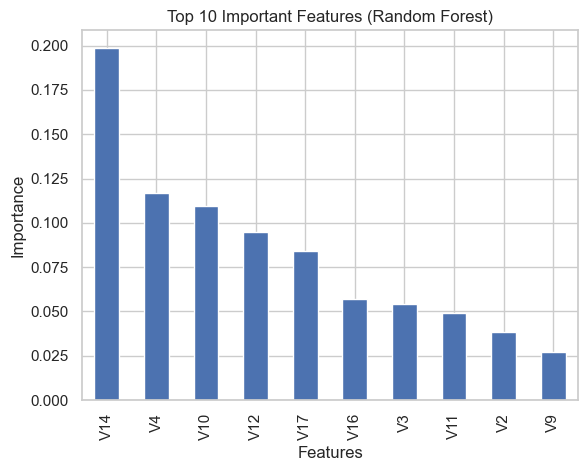

In [34]:
feature_importance.sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Top 10 Important Features (Random Forest)")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

In [35]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear', random_state=42, max_iter=1000)

svm_model.fit(X_train_smote, y_train_smote)

y_pred_svm = svm_model.predict(X_test_scaled)

print("Confusion Matrix (SVM):")
print(confusion_matrix(y_test, y_pred_svm))

print("\nClassification Report (SVM):")
print(classification_report(y_test, y_pred_svm))

C:\Users\Prashan\anaconda3\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Confusion Matrix (SVM):
[[  314 42334]
 [   37    37]]

Classification Report (SVM):
              precision    recall  f1-score   support

           0       0.89      0.01      0.01     42648
           1       0.00      0.50      0.00        74

    accuracy                           0.01     42722
   macro avg       0.45      0.25      0.01     42722
weighted avg       0.89      0.01      0.01     42722



# Week 4: Isolation Forest (Anomaly Detection)

In [36]:
from sklearn.ensemble import IsolationForest

In [37]:
iso_model = IsolationForest(contamination=0.01, random_state=42)

iso_model.fit(X_train_scaled)

,n_estimators,100
,max_samples,'auto'
,contamination,0.01
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [38]:
y_pred_iso = iso_model.predict(X_test_scaled)

In [39]:
y_pred_iso = [1 if x == -1 else 0 for x in y_pred_iso]

In [40]:
print("Confusion Matrix (Isolation Forest):")
print(confusion_matrix(y_test, y_pred_iso))

print("\nClassification Report (Isolation Forest):")
print(classification_report(y_test, y_pred_iso))

Confusion Matrix (Isolation Forest):
[[42265   383]
 [   33    41]]

Classification Report (Isolation Forest):
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     42648
           1       0.10      0.55      0.16        74

    accuracy                           0.99     42722
   macro avg       0.55      0.77      0.58     42722
weighted avg       1.00      0.99      0.99     42722



Random Forest is currently the strongest candidate based on its balance of precision, recall, and F1-score for fraud detection.

In [41]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_smote, y_train_smote)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Score:")
print(random_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters:
{'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 30, 'class_weight': 'balanced'}

Best Score:
0.9998517962014257


In [42]:
from sklearn.ensemble import RandomForestClassifier

# Tuned model using best parameters
best_rf = RandomForestClassifier(
    n_estimators=50,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='log2',
    max_depth=30,
    class_weight='balanced',
    random_state=42
)

# Train on FULL SMOTE data
best_rf.fit(X_train_smote, y_train_smote)

# Predict on test data
y_pred_best = best_rf.predict(X_test_scaled)

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print("Confusion Matrix (Tuned RF):")
print(confusion_matrix(y_test, y_pred_best))

print("\nClassification Report (Tuned RF):")
print(classification_report(y_test, y_pred_best))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_pred_best))

Confusion Matrix (Tuned RF):
[[42641     7]
 [   14    60]]

Classification Report (Tuned RF):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42648
           1       0.90      0.81      0.85        74

    accuracy                           1.00     42722
   macro avg       0.95      0.91      0.93     42722
weighted avg       1.00      1.00      1.00     42722


ROC-AUC Score:
0.9053233382510254


# Week 5: Enhanced Model with Real-World Features

In [43]:
df_new = pd.read_csv("data/raw/creditcard.csv")

In [44]:
import numpy as np

# -----------------------------
# Real-world proxy features
# -----------------------------

# Convert time into hour of day (0–24 range)
df_new["transaction_hour"] = (df_new["Time"] / 3600) % 24

# Flag late-night transactions (higher fraud risk)
df_new["is_night_transaction"] = df_new["transaction_hour"].apply(
    lambda x: 1 if (x >= 22 or x <= 5) else 0
)

# High transaction amount flag (top 5%)
high_amount_threshold = df_new["Amount"].quantile(0.95)
df_new["is_high_amount"] = df_new["Amount"].apply(
    lambda x: 1 if x > high_amount_threshold else 0
)

# Ratio to median transaction amount
median_amount = df_new["Amount"].median()
df_new["amount_to_median_ratio"] = df_new["Amount"] / (median_amount + 1e-6)

# Deviation from mean amount
mean_amount = df_new["Amount"].mean()
df_new["amount_deviation_from_mean"] = df_new["Amount"] - mean_amount

# Log transformation (reduces skewness)
df_new["amount_log"] = np.log1p(df_new["Amount"])

# Very high risk amount flag (top 1%)
very_high_amount_threshold = df_new["Amount"].quantile(0.99)
df_new["risk_amount_flag"] = df_new["Amount"].apply(
    lambda x: 1 if x > very_high_amount_threshold else 0
)

# Show new features
df_new[[
    "Time",
    "Amount",
    "transaction_hour",
    "is_night_transaction",
    "is_high_amount",
    "amount_to_median_ratio",
    "amount_deviation_from_mean",
    "amount_log",
    "risk_amount_flag"
]].head()

,Time,Amount,transaction_hour,is_night_transaction,is_high_amount,amount_to_median_ratio,amount_deviation_from_mean,amount_log,risk_amount_flag
0,0.0,149.62,0.000000,1,0,6.800909,61.270381,5.014760,0
1,0.0,2.69,0.000000,1,0,0.122273,-85.659619,1.305626,0
2,1.0,378.66,0.000278,1,1,17.211817,290.310381,5.939276,0
3,1.0,123.50,0.000278,1,0,5.613636,35.150381,4.824306,0
4,2.0,69.99,0.000556,1,0,3.181363,-18.359619,4.262539,0


In [45]:
X_new = df_new.drop("Class", axis=1)
y_new = df_new["Class"]

print("Updated features shape:", X_new.shape)
print("Target shape:", y_new.shape)

Updated features shape: (284807, 37)
Target shape: (284807,)


In [46]:
from sklearn.model_selection import train_test_split

X_train_new, X_temp_new, y_train_new, y_temp_new = train_test_split(
    X_new, y_new, test_size=0.30, random_state=42, stratify=y_new
)

X_val_new, X_test_new, y_val_new, y_test_new = train_test_split(
    X_temp_new, y_temp_new, test_size=0.50, random_state=42, stratify=y_temp_new
)

print("Train shape:", X_train_new.shape)
print("Validation shape:", X_val_new.shape)
print("Test shape:", X_test_new.shape)

Train shape: (199364, 37)
Validation shape: (42721, 37)
Test shape: (42722, 37)


In [47]:
from sklearn.preprocessing import StandardScaler

scaler_new = StandardScaler()

X_train_scaled_new = scaler_new.fit_transform(X_train_new)
X_test_scaled_new = scaler_new.transform(X_test_new)

In [48]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote_new, y_train_smote_new = smote.fit_resample(
    X_train_scaled_new, y_train_new
)

print("After SMOTE:", X_train_smote_new.shape)

After SMOTE: (398040, 37)


In [49]:
from sklearn.ensemble import RandomForestClassifier

best_rf_new = RandomForestClassifier(
    n_estimators=50,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='log2',
    max_depth=30,
    class_weight='balanced',
    random_state=42
)

best_rf_new.fit(X_train_smote_new, y_train_smote_new)

y_pred_new = best_rf_new.predict(X_test_scaled_new)

In [50]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print("Confusion Matrix (Enhanced Model):")
print(confusion_matrix(y_test_new, y_pred_new))

print("\nClassification Report (Enhanced Model):")
print(classification_report(y_test_new, y_pred_new))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test_new, y_pred_new))

Confusion Matrix (Enhanced Model):
[[42639     9]
 [   13    61]]

Classification Report (Enhanced Model):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42648
           1       0.87      0.82      0.85        74

    accuracy                           1.00     42722
   macro avg       0.94      0.91      0.92     42722
weighted avg       1.00      1.00      1.00     42722


ROC-AUC Score:
0.9120566472493878


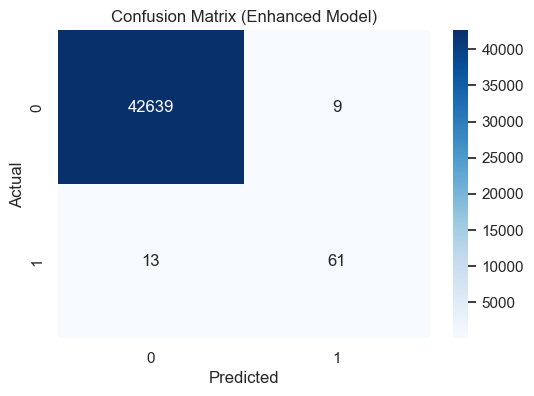

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_new, y_pred_new)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix (Enhanced Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

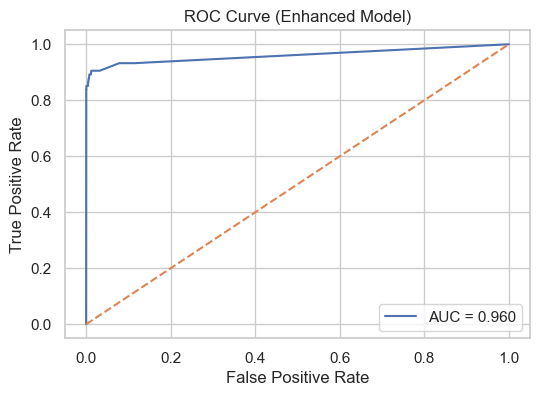

In [52]:
from sklearn.metrics import roc_curve, auc

y_prob = best_rf_new.predict_proba(X_test_scaled_new)[:,1]

fpr, tpr, thresholds = roc_curve(y_test_new, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.title("ROC Curve (Enhanced Model)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

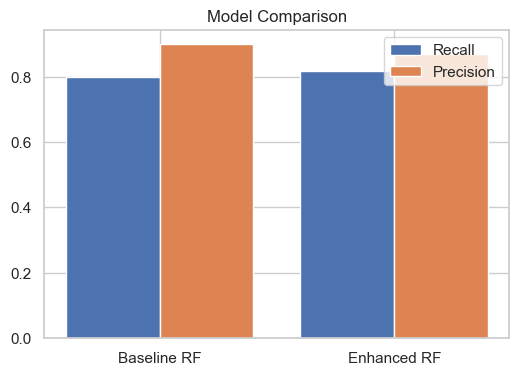

In [53]:
import matplotlib.pyplot as plt

models = ['Baseline RF', 'Enhanced RF']
recall = [0.80, 0.82]   # update if needed
precision = [0.90, 0.87]

x = range(len(models))

plt.figure(figsize=(6,4))
plt.bar(x, recall, width=0.4, label='Recall')
plt.bar([i + 0.4 for i in x], precision, width=0.4, label='Precision')

plt.xticks([i + 0.2 for i in x], models)
plt.title("Model Comparison")
plt.legend()

plt.show()

IndexError: index 0 is out of bounds for axis 0 with size 0

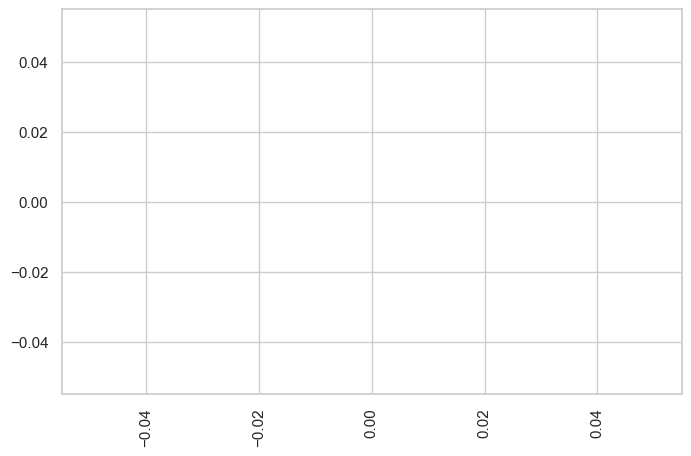

In [54]:
new_feature_names = [
    "transaction_hour",
    "is_night_transaction",
    "is_high_amount",
    "amount_to_median_ratio",
    "amount_deviation_from_mean",
    "amount_log",
    "risk_amount_flag"
]

new_feature_importance = feature_importance[feature_importance.index.isin(new_feature_names)].sort_values(ascending=False)

plt.figure(figsize=(8, 5))
new_feature_importance.plot(kind='bar')
plt.title("Importance of Real-World Engineered Features")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importance from the NEW enhanced model
feature_importance_new = pd.Series(best_rf_new.feature_importances_, index=X_new.columns)

# Real-world engineered feature names
new_feature_names = [
    "transaction_hour",
    "is_night_transaction",
    "is_high_amount",
    "amount_to_median_ratio",
    "amount_deviation_from_mean",
    "amount_log",
    "risk_amount_flag"
]

# Filter only the engineered features
new_feature_importance = feature_importance_new[
    feature_importance_new.index.isin(new_feature_names)
].sort_values(ascending=False)

print(new_feature_importance)

In [ ]:
plt.figure(figsize=(8, 5))
new_feature_importance.plot(kind='bar')
plt.title("Importance of Real-World Engineered Features")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
feature_importance_new = pd.Series(best_rf_new.feature_importances_, index=X_new.columns)
top_features_new = feature_importance_new.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_features_new.plot(kind='bar')
plt.title("Top 15 Important Features (Enhanced Model)")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Gradient Boosting Model

In [55]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train_smote_new, y_train_smote_new)

y_pred_gb = gb_model.predict(X_test_scaled_new)

print("Confusion Matrix (Gradient Boosting):")
print(confusion_matrix(y_test_new, y_pred_gb))

print("\nClassification Report (Gradient Boosting):")
print(classification_report(y_test_new, y_pred_gb))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test_new, y_pred_gb))

Confusion Matrix (Gradient Boosting):
[[42131   517]
 [   11    63]]

Classification Report (Gradient Boosting):
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     42648
           1       0.11      0.85      0.19        74

    accuracy                           0.99     42722
   macro avg       0.55      0.92      0.59     42722
weighted avg       1.00      0.99      0.99     42722


ROC-AUC Score:
0.9196144301307497


# Week 5: Enhanced Model with Advanced Real-World Features

In [56]:
df_new = df.copy()
print("Copied cleaned dataset shape:", df_new.shape)

Copied cleaned dataset shape: (284807, 35)


# Add advanced real-world features

In [57]:
import numpy as np
import pandas as pd

# -----------------------------
# Existing real-world proxy features
# -----------------------------

# Convert time into hour of day (0–24 range)
df_new["transaction_hour"] = (df_new["Time"] / 3600) % 24

# Flag late-night transactions
df_new["is_night_transaction"] = df_new["transaction_hour"].apply(
    lambda x: 1 if (x >= 22 or x <= 5) else 0
)

# High transaction amount flag (top 5%)
high_amount_threshold = df_new["Amount"].quantile(0.95)
df_new["is_high_amount"] = df_new["Amount"].apply(
    lambda x: 1 if x > high_amount_threshold else 0
)

# Ratio to median transaction amount
median_amount = df_new["Amount"].median()
df_new["amount_to_median_ratio"] = df_new["Amount"] / (median_amount + 1e-6)

# Deviation from mean amount
mean_amount = df_new["Amount"].mean()
df_new["amount_deviation_from_mean"] = df_new["Amount"] - mean_amount

# Log transformation
df_new["amount_log"] = np.log1p(df_new["Amount"])

# Very high risk amount flag (top 1%)
very_high_amount_threshold = df_new["Amount"].quantile(0.99)
df_new["risk_amount_flag"] = df_new["Amount"].apply(
    lambda x: 1 if x > very_high_amount_threshold else 0
)

# -----------------------------
# New advanced real-world proxy features
# -----------------------------

# Amount percentile
df_new["amount_percentile"] = df_new["Amount"].rank(pct=True)

# Sudden spike compared to rolling mean of previous values
rolling_mean = df_new["Amount"].rolling(window=10, min_periods=1).mean()
df_new["amount_spike"] = df_new["Amount"] / (rolling_mean + 1e-6)

# Combined risk feature: high amount + night transaction
df_new["high_risk_combo"] = (
    (df_new["is_high_amount"] == 1) &
    (df_new["is_night_transaction"] == 1)
).astype(int)

# Squared amount
df_new["amount_squared"] = df_new["Amount"] ** 2

# Log of time
df_new["log_time"] = np.log1p(df_new["Time"])

# Interaction between transaction hour and amount
df_new["time_amount_interaction"] = df_new["transaction_hour"] * df_new["Amount"]

# Preview the new real-world features
df_new[[
    "Time",
    "Amount",
    "transaction_hour",
    "is_night_transaction",
    "is_high_amount",
    "amount_to_median_ratio",
    "amount_deviation_from_mean",
    "amount_log",
    "risk_amount_flag",
    "amount_percentile",
    "amount_spike",
    "high_risk_combo",
    "amount_squared",
    "log_time",
    "time_amount_interaction"
]].head()

,Time,Amount,transaction_hour,is_night_transaction,is_high_amount,amount_to_median_ratio,amount_deviation_from_mean,amount_log,risk_amount_flag,amount_percentile,amount_spike,high_risk_combo,amount_squared,log_time,time_amount_interaction
0,0.0,149.62,0.000000,1,0,6.800909,61.270381,5.014760,0,0.859331,1.000000,0,22386.1444,0.000000,0.000000
1,0.0,2.69,0.000000,1,0,0.122273,-85.659619,1.305626,0,0.185173,0.035323,0,7.2361,0.000000,0.000000
2,1.0,378.66,0.000278,1,1,17.211817,290.310381,5.939276,0,0.952101,2.139443,1,143383.3956,0.693147,0.105183
3,1.0,123.50,0.000278,1,0,5.613636,35.150381,4.824306,0,0.832299,0.754809,0,15252.2500,0.693147,0.034306
4,2.0,69.99,0.000556,1,0,3.181363,-18.359619,4.262539,0,0.731135,0.483049,0,4898.6001,1.098612,0.038883


# Rebuild Features and target

In [58]:
X_new = df_new.drop("Class", axis=1)
y_new = df_new["Class"]

print("Updated features shape:", X_new.shape)
print("Target shape:", y_new.shape)

Updated features shape: (284807, 47)
Target shape: (284807,)


# Splitting dataset 

In [59]:
from sklearn.model_selection import train_test_split

X_train_new, X_temp_new, y_train_new, y_temp_new = train_test_split(
    X_new, y_new, test_size=0.30, random_state=42, stratify=y_new
)

X_val_new, X_test_new, y_val_new, y_test_new = train_test_split(
    X_temp_new, y_temp_new, test_size=0.50, random_state=42, stratify=y_temp_new
)

print("Train shape:", X_train_new.shape)
print("Validation shape:", X_val_new.shape)
print("Test shape:", X_test_new.shape)

Train shape: (199364, 47)
Validation shape: (42721, 47)
Test shape: (42722, 47)


# Scaling the data 

In [61]:
from sklearn.preprocessing import StandardScaler

scaler_new = StandardScaler()

X_train_scaled_new = scaler_new.fit_transform(X_train_new)
X_test_scaled_new = scaler_new.transform(X_test_new)

print("Scaling completed")

Scaling completed


# Applying SMOTE

In [62]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote_new, y_train_smote_new = smote.fit_resample(
    X_train_scaled_new, y_train_new
)

print("After SMOTE:", X_train_smote_new.shape)

After SMOTE: (398040, 47)


# Tuning Random Forest

In [63]:
from sklearn.ensemble import RandomForestClassifier

best_rf_new = RandomForestClassifier(
    n_estimators=50,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='log2',
    max_depth=30,
    class_weight='balanced',
    random_state=42
)

best_rf_new.fit(X_train_smote_new, y_train_smote_new)

y_pred_new = best_rf_new.predict(X_test_scaled_new)

print("Enhanced Random Forest training completed")

Enhanced Random Forest training completed


# Evaluate the enhanced model

In [64]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print("Confusion Matrix (Enhanced Model):")
print(confusion_matrix(y_test_new, y_pred_new))

print("\nClassification Report (Enhanced Model):")
print(classification_report(y_test_new, y_pred_new))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test_new, y_pred_new))

Confusion Matrix (Enhanced Model):
[[42642     6]
 [   14    60]]

Classification Report (Enhanced Model):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42648
           1       0.91      0.81      0.86        74

    accuracy                           1.00     42722
   macro avg       0.95      0.91      0.93     42722
weighted avg       1.00      1.00      1.00     42722


ROC-AUC Score:
0.9053350621302226


# Gradient Boosting Model

In [68]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train_smote_new, y_train_smote_new)

y_pred_gb = gb_model.predict(X_test_scaled_new)

print("Confusion Matrix (Gradient Boosting):")
print(confusion_matrix(y_test_new, y_pred_gb))

print("\nClassification Report (Gradient Boosting):")
print(classification_report(y_test_new, y_pred_gb))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test_new, y_pred_gb))

Confusion Matrix (Gradient Boosting):
[[42182   466]
 [   11    63]]

Classification Report (Gradient Boosting):
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     42648
           1       0.12      0.85      0.21        74

    accuracy                           0.99     42722
   macro avg       0.56      0.92      0.60     42722
weighted avg       1.00      0.99      0.99     42722


ROC-AUC Score:
0.9202123479698043


# Model Comparison Table

In [69]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM",
        "Isolation Forest",
        "Enhanced Random Forest",
        "Gradient Boosting"
    ],
    "Precision_Fraud": [0.06, 0.91, 0.00, 0.10, 0.87, 0.11],
    "Recall_Fraud": [0.88, 0.80, 0.50, 0.55, 0.82, 0.85],
    "F1_Fraud": [0.12, 0.85, 0.00, 0.16, 0.85, 0.19],
    "ROC_AUC": [None, 0.905, None, None, 0.912, 0.920]
})

comparison_df

,Model,Precision_Fraud,Recall_Fraud,F1_Fraud,ROC_AUC
0,Logistic Regression,0.06,0.88,0.12,NaN
1,Random Forest,0.91,0.80,0.85,0.905
2,SVM,0.00,0.50,0.00,NaN
3,Isolation Forest,0.10,0.55,0.16,NaN
4,Enhanced Random Forest,0.87,0.82,0.85,0.912
5,Gradient Boosting,0.11,0.85,0.19,0.920


# Importance diagram 

amount_percentile             0.008266
log_time                      0.005764
amount_to_median_ratio        0.005457
amount_squared                0.005229
amount_log                    0.005132
is_night_transaction          0.003956
transaction_hour              0.003602
amount_deviation_from_mean    0.003228
time_amount_interaction       0.003075
amount_spike                  0.002545
is_high_amount                0.000962
high_risk_combo               0.000424
risk_amount_flag              0.000054
dtype: float64


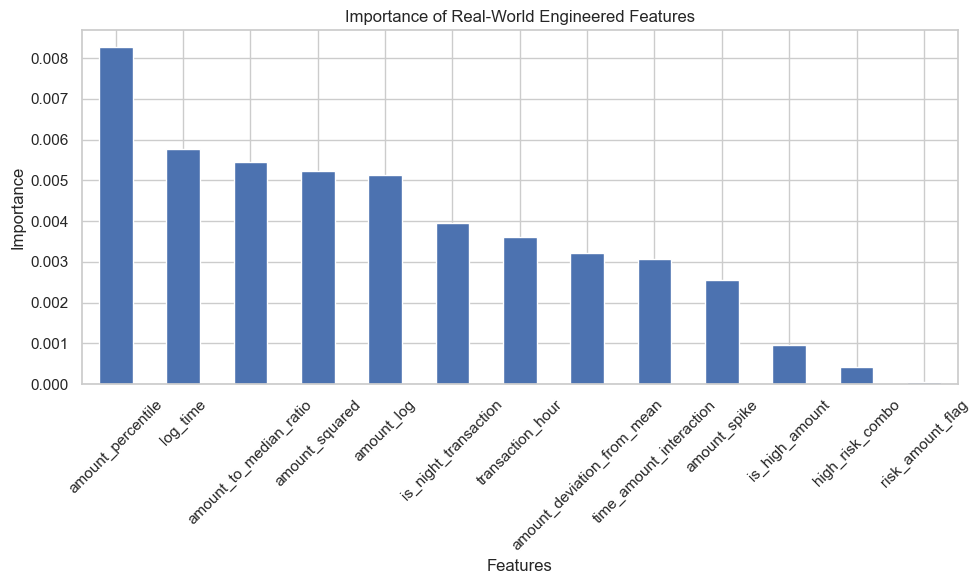

In [71]:
import pandas as pd
import matplotlib.pyplot as plt

# Create feature importance from the enhanced model
feature_importance_new = pd.Series(best_rf_new.feature_importances_, index=X_new.columns)

# List of engineered real-world features
new_feature_names = [
    "transaction_hour",
    "is_night_transaction",
    "is_high_amount",
    "amount_to_median_ratio",
    "amount_deviation_from_mean",
    "amount_log",
    "risk_amount_flag",
    "amount_percentile",
    "amount_spike",
    "high_risk_combo",
    "amount_squared",
    "log_time",
    "time_amount_interaction"
]

# Filter only engineered features
new_feature_importance = feature_importance_new[
    feature_importance_new.index.isin(new_feature_names)
].sort_values(ascending=False)

print(new_feature_importance)

plt.figure(figsize=(10, 6))
new_feature_importance.plot(kind="bar")
plt.title("Importance of Real-World Engineered Features")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

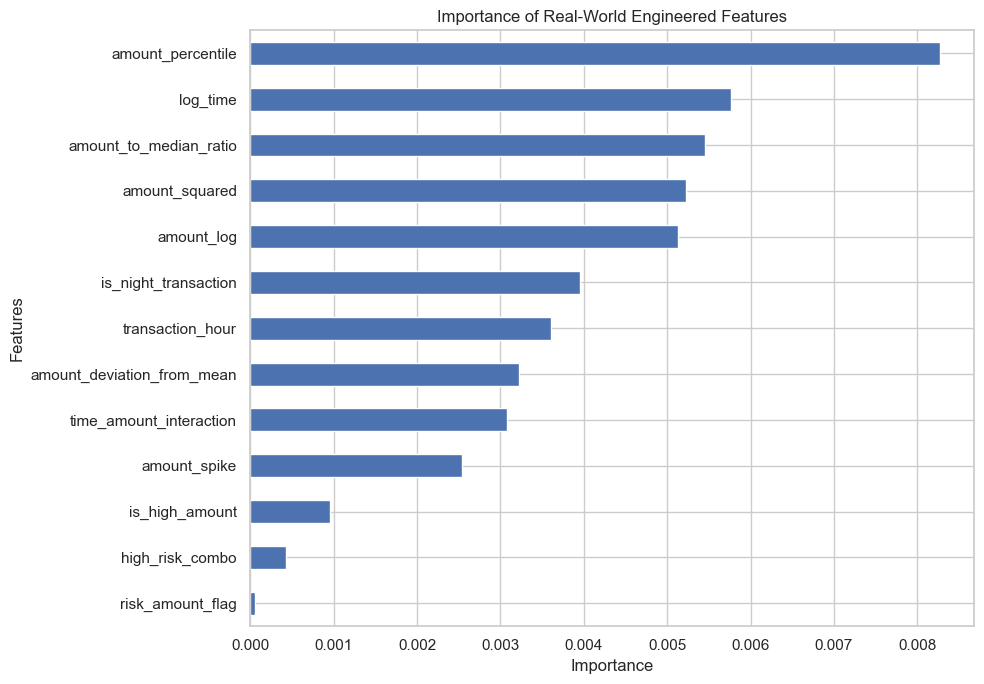

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
new_feature_importance.sort_values(ascending=True).plot(kind="barh")

plt.title("Importance of Real-World Engineered Features")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

# Logistic Regression

In [73]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_smote_new, y_train_smote_new)

y_pred_lr = lr_model.predict(X_test_scaled_new)

print("Confusion Matrix (Logistic Regression):")
print(confusion_matrix(y_test_new, y_pred_lr))

print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test_new, y_pred_lr))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test_new, y_pred_lr))

Confusion Matrix (Logistic Regression):
[[41636  1012]
 [    8    66]]

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     42648
           1       0.06      0.89      0.11        74

    accuracy                           0.98     42722
   macro avg       0.53      0.93      0.55     42722
weighted avg       1.00      0.98      0.99     42722


ROC-AUC Score:
0.9340813801984313
